# Stage 3 — Circuit Design

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `02_quantum_encoding.ipynb`
**Next:** → `04_classical_training.ipynb`

---

Stage 00 derived the *math* of the Gaussian-loading ansatz (Ry + CNOT). Stage 02 derived the *math* of the asset-qubit encoding ($\tilde\alpha$, $\tilde\beta$, and the $n{+}1$-gate binary-decomposition trick), and proved it with a hand-written NumPy simulator. This notebook is where those two pieces of math finally become **one real Qiskit circuit** — the actual object that Stage 4 will train and Stage 5 will transpile.


## 1. What Is "Circuit Design" Here? (General Overview)

In quantum computing, **circuit design** is the step of turning an abstract mathematical description of an algorithm (gates, parameters, qubit connections) into an actual, executable circuit object — something a simulator or real device can run. It sits between "we know what operations we need" and "we can press run."

Two design decisions matter most at this stage:

- **Qubit layout** — which physical/logical qubit plays which role. Here: qubits $0, \dots, n{-}1$ form the **z-register** (the latent risk-factor register), and qubit $n$ is the **asset qubit** (the one whose measurement encodes the conditional default probability).
- **Parameterization** — which gate angles are *fixed numbers* (computed analytically, like $\tilde\alpha, \tilde\beta$ from Stage 02) and which are *symbolic, trainable parameters* (like the z-register's rotation angles, which Stage 4 hasn't found the right values for yet). Qiskit represents the latter with `Parameter` objects — placeholders that get bound to numbers later, without rebuilding the circuit.


## 2. Why We Build It This Way

1. **It's the direct assembly of two already-derived pieces.** Nothing new is being invented here — Stage 00 gave us the z-register ansatz structure, Stage 02 gave us the asset-qubit gate angles and proved the mechanism numerically. Stage 03's job is purely architectural: wire them together correctly, as one Qiskit `QuantumCircuit`.

2. **Using `Parameter` objects (not fixed numbers) for the z-register keeps the circuit reusable.** Stage 4 needs to evaluate the same circuit structure hundreds of times with different candidate angles (that's what training *is*). Building the circuit once with symbolic parameters, then binding new values each iteration, is far cheaper than constructing a brand-new circuit every time.

3. **It matches the base paper's actual circuit (Fig. 1).** For the 2-qubit z-register case, the circuit built here is structurally identical to the paper's 3-qubit GCI circuit: $R_y(\theta_0)$ on q0, $R_y(\theta_1)$ on q1, a CNOT entangler, then the asset qubit q2 receiving one unconditional $R_y(\tilde\beta)$ and two controlled rotations ($\tilde\alpha$ from q0, $2\tilde\alpha$ from q1).


## 3. Where This Fits in the Project Pipeline

This is **Stage 3 of 9**. Inputs and outputs:

- **Input:** the ansatz structure from `00_overview.ipynb` (§3.1) and the register-adapted encoding parameters $\tilde\alpha, \tilde\beta$ from `02_quantum_encoding.ipynb`.
- **Output:** a parameterized `QuantumCircuit` object (one for the 2-qubit z-register case, one for the 3-qubit case) with symbolic `Parameter`s on the z-register rotations — ready for Stage 4 to plug values into and train.

Nothing gets trained or transpiled here — this notebook only builds and sanity-checks the circuit's *structure*.


## 4. Circuit Architecture

### 4.1 The two building blocks, recapped

| Block | Qubits | Gates | Parameters | Where derived |
|---|---|---|---|---|
| **Gaussian loader** (z-register) | qubits $0 \dots n{-}1$ | $R_y(\theta_i)$ on each register qubit, then CNOT entanglers | $\theta_0, \dots, \theta_{n-1}$ — **trainable** | Stage 00, §3.1 |
| **Asset encoder** | qubit $n$ (target), controlled by register qubits | one unconditional $R_y(2\tilde\beta)$, then $n$ controlled-$R_y(2\tilde\alpha \cdot 2^k)$ gates | $\tilde\alpha, \tilde\beta$ — **fixed, analytic** | Stage 02, §4.3–4.4 |

### 4.2 Entangler pattern

For $n=2$: a single CNOT, control q0 → target q1.
For $n=3$: two CNOTs, both controlled by q0 — one targeting q1, one targeting q2 (a "star" pattern centered on q0), matching the base paper's 3-qubit Gaussian-loading circuit (Fig. 3).

### 4.3 Full qubit layout

```
2-qubit z-register case (3 qubits total, matches paper Fig. 1):

  q0: --[Ry(theta0)]--o-------[o]-------------------
                       |        |
  q1: --[Ry(theta1)]--X--------|--[o]----------------
                                |   |
  q2: -------------------------[Ry(beta~)]--[Ry(alpha~)]--[Ry(2 alpha~)]--
      (asset qubit)                          ^control:q0     ^control:q1


3-qubit z-register case (4 qubits total, extension):

  q0: --[Ry(theta0)]--o-----o-----------------------------------------
                       |     |
  q1: --[Ry(theta1)]--X-----|--------[o]-------------------------------
                             |         |
  q2: --[Ry(theta2)]--------X---------|-------[o]-----------------------
                                       |        |
  q3: ----------------------------[Ry(beta~)]--[Ry(alpha~)]--[Ry(2a~)]--[Ry(4a~)]
      (asset qubit)                             ^ctrl:q0       ^ctrl:q1  ^ctrl:q2
```


## 5. Implementation

### 5.1 Loading the encoding parameters from Stage 02

We reuse the exact $\tilde\alpha, \tilde\beta$ values Stage 02 computed and saved — this is what makes the pipeline a *pipeline* rather than a set of disconnected notebooks. If `results/quantum_encoding_params.json` isn't found (e.g. this notebook is run standalone), we fall back to recomputing them with the same formulas.


In [1]:
import os
os.makedirs("results/figures", exist_ok=True)   # every output of this notebook goes into results/
import json
import numpy as np
from scipy.stats import norm

p0, rho, z_max = 0.25, 0.027, 3.0

def pd_given_z(z, p0=p0, rho=rho):
    numerator = norm.ppf(p0) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

try:
    with open("results/quantum_encoding_params.json") as f:
        enc = json.load(f)
    print("Loaded results/quantum_encoding_params.json from Stage 02.")
except FileNotFoundError:
    print("Stage 02 output not found -- recomputing alpha, beta, alpha_tilde, beta_tilde locally.")
    z_fit = np.linspace(-z_max, z_max, 400)
    theta_fit = np.arcsin(np.sqrt(pd_given_z(z_fit)))
    alpha, beta = np.polyfit(z_fit, theta_fit, 1)
    enc = {"register_adapted": {}}
    for n_qubits in (2, 3):
        n_bins = 2 ** n_qubits
        slope = (2 * z_max) / (n_bins - 1)
        a_tilde = alpha * slope
        b_tilde = beta - alpha * z_max
        enc["register_adapted"][f"{n_qubits}_qubit"] = {"alpha_tilde": a_tilde, "beta_tilde": b_tilde}

alpha_tilde_2q = enc["register_adapted"]["2_qubit"]["alpha_tilde"]
beta_tilde_2q  = enc["register_adapted"]["2_qubit"]["beta_tilde"]
alpha_tilde_3q = enc["register_adapted"]["3_qubit"]["alpha_tilde"]
beta_tilde_3q  = enc["register_adapted"]["3_qubit"]["beta_tilde"]

print(f"\n2-qubit register:  alpha_tilde = {alpha_tilde_2q:.6f}   beta_tilde = {beta_tilde_2q:.6f}")
print(f"3-qubit register:  alpha_tilde = {alpha_tilde_3q:.6f}   beta_tilde = {beta_tilde_3q:.6f}")


Loaded results/quantum_encoding_params.json from Stage 02.

2-qubit register:  alpha_tilde = -0.120979   beta_tilde = 0.705516
3-qubit register:  alpha_tilde = -0.051848   beta_tilde = 0.705516


### 5.2 Building the circuit

`build_gci_circuit()` assembles both blocks from §4.1 into one `QuantumCircuit`, using Qiskit `Parameter` objects for the (still-untrained) z-register rotation angles.


In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

def build_gci_circuit(n_z_qubits, alpha_tilde, beta_tilde, add_measurement=True, add_barrier=True):
    """Builds the full GCI quantum circuit:
        - z-register (qubits 0..n_z_qubits-1): Ry(theta_i) ansatz + CNOT star-entangler
        - asset qubit (qubit n_z_qubits): unconditional Ry(2*beta_tilde) +
          n_z_qubits controlled-Ry(2*alpha_tilde*2^k) gates, one per register qubit

    Returns: (QuantumCircuit, list_of_theta_Parameters)
    """
    n_total = n_z_qubits + 1
    asset_qubit = n_z_qubits
    qc = QuantumCircuit(n_total, n_total, name=f"GCI_{n_z_qubits}q_register")

    # --- Block 1: Gaussian-loading ansatz on the z-register (trainable) ---
    thetas = [Parameter(f"theta_{i}") for i in range(n_z_qubits)]
    for i in range(n_z_qubits):
        qc.ry(thetas[i], i)
    for i in range(1, n_z_qubits):
        qc.cx(0, i)   # star-pattern entangler, control = qubit 0

    if add_barrier:
        qc.barrier()

    # --- Block 2: asset-qubit conditional encoding (fixed, analytic) ---
    qc.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        qc.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)

    if add_measurement:
        qc.measure(range(n_total), range(n_total))

    return qc, thetas

qc_2q, thetas_2q = build_gci_circuit(2, alpha_tilde_2q, beta_tilde_2q)
qc_3q, thetas_3q = build_gci_circuit(3, alpha_tilde_3q, beta_tilde_3q)

print("2-qubit z-register circuit -- parameters:", thetas_2q)
print("3-qubit z-register circuit -- parameters:", thetas_3q)


2-qubit z-register circuit -- parameters: [Parameter(theta_0), Parameter(theta_1)]
3-qubit z-register circuit -- parameters: [Parameter(theta_0), Parameter(theta_1), Parameter(theta_2)]


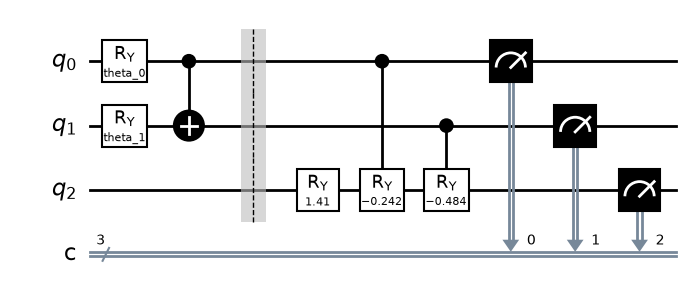

In [3]:
# ---- Draw both circuits ----
fig1 = qc_2q.draw('mpl', style={'name': 'bw'})
fig1.savefig('results/figures/stage03_circuit_2q_register.png', dpi=150, bbox_inches='tight')
fig1


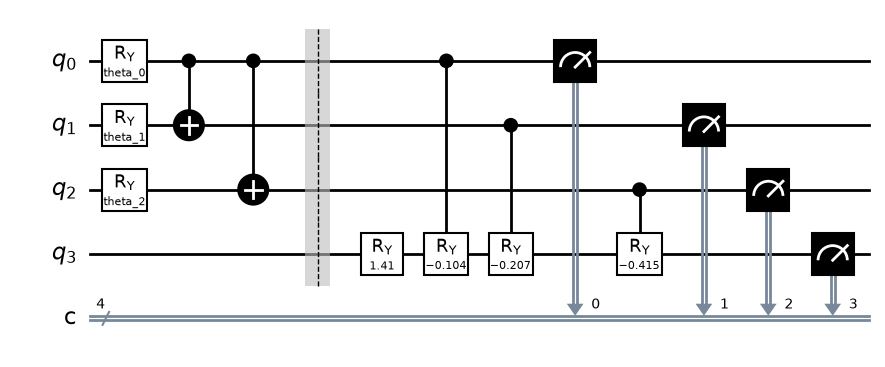

In [4]:
fig2 = qc_3q.draw('mpl', style={'name': 'bw'})
fig2.savefig('results/figures/stage03_circuit_3q_register.png', dpi=150, bbox_inches='tight')
fig2


### 5.3 Gate count and depth

Circuit depth and gate count matter a great deal once we get to transpilation (Stage 05) and hardware execution (Stage 07) — shallower, simpler circuits accumulate less noise. We check these numbers now, on the *idealized* (pre-transpilation) circuit, as a baseline to compare against later.


In [5]:
for label, qc in [("2-qubit z-register (3 total qubits)", qc_2q),
                   ("3-qubit z-register (4 total qubits)", qc_3q)]:
    print(f"--- {label} ---")
    print(f"  Depth       : {qc.depth()}")
    print(f"  Gate counts : {dict(qc.count_ops())}")
    print()


--- 2-qubit z-register (3 total qubits) ---
  Depth       : 6
  Gate counts : {'ry': 3, 'measure': 3, 'cry': 2, 'cx': 1, 'barrier': 1}

--- 3-qubit z-register (4 total qubits) ---
  Depth       : 8
  Gate counts : {'ry': 4, 'measure': 4, 'cry': 3, 'cx': 2, 'barrier': 1}



### 5.4 Sanity check — does the real Qiskit circuit agree with Stage 02's NumPy proof?

Stage 02 hand-built a NumPy statevector simulator and proved, basis-state by basis-state, that the $n{+}1$-gate encoding reproduces $\sin^2(\tilde\alpha b + \tilde\beta)$ exactly. Here we run the **same test**, but on the **real Qiskit circuit** (just the asset-encoding block, with the z-register forced into each basis state via $X$ gates, no ansatz/training involved yet) — using exact statevector simulation, no shot noise. If Stage 02's math was translated into Qiskit correctly, every row should match.


In [6]:
from qiskit.quantum_info import Statevector

def asset_probability_for_basis_state(n_z_qubits, b, alpha_tilde, beta_tilde):
    """Prepares the z-register in basis state |b>, applies only the asset-encoding
    block (no ansatz), and returns the exact P(asset qubit = 1) via statevector simulation.
    """
    n_total = n_z_qubits + 1
    asset_qubit = n_z_qubits
    qc = QuantumCircuit(n_total)

    # prepare register in basis state b via X gates on the appropriate qubits
    for k in range(n_z_qubits):
        if (b >> k) & 1:
            qc.x(k)

    # asset-encoding block only (no measurement -- we want the exact statevector)
    qc.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        qc.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)

    sv = Statevector.from_instruction(qc)
    p0_asset, p1_asset = sv.probabilities(qargs=[asset_qubit])
    return p1_asset

def discretize_z(n_qubits, z_max=z_max):
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    return -z_max + (2 * z_max) * b / (n_bins - 1)

for n_qubits, a_tilde, b_tilde in [(2, alpha_tilde_2q, beta_tilde_2q),
                                    (3, alpha_tilde_3q, beta_tilde_3q)]:
    z_grid = discretize_z(n_qubits)
    print(f"=== {n_qubits}-qubit register: Qiskit circuit vs. Stage 02's NumPy result ===")
    print(f"{'b':>3} | {'z(b)':>7} | {'sin^2(a~b+b~)':>14} | {'Qiskit statevector':>18} | {'match?':>7}")
    print("-" * 62)
    for b in range(2 ** n_qubits):
        formula_pred = np.sin(a_tilde * b + b_tilde) ** 2
        qiskit_pred = asset_probability_for_basis_state(n_qubits, b, a_tilde, b_tilde)
        match = np.isclose(formula_pred, qiskit_pred, atol=1e-9)
        print(f"{b:3d} | {z_grid[b]:7.3f} | {formula_pred:14.6f} | {qiskit_pred:18.6f} | {str(match):>7}")
    print()


=== 2-qubit register: Qiskit circuit vs. Stage 02's NumPy result ===
  b |    z(b) |  sin^2(a~b+b~) | Qiskit statevector |  match?
--------------------------------------------------------------
  0 |  -3.000 |       0.420457 |           0.420457 |    True
  1 |  -1.000 |       0.304498 |           0.304498 |    True
  2 |   1.000 |       0.199929 |           0.199929 |    True
  3 |   3.000 |       0.112841 |           0.112841 |    True

=== 3-qubit register: Qiskit circuit vs. Stage 02's NumPy result ===
  b |    z(b) |  sin^2(a~b+b~) | Qiskit statevector |  match?
--------------------------------------------------------------
  0 |  -3.000 |       0.420457 |           0.420457 |    True
  1 |  -2.143 |       0.369789 |           0.369789 |    True
  2 |  -1.286 |       0.320519 |           0.320519 |    True
  3 |  -0.429 |       0.273177 |           0.273177 |    True
  4 |   0.429 |       0.228272 |           0.228272 |    True
  5 |   1.286 |       0.186286 |           0.186286 |

### 5.5 Preview: running the *full* circuit with placeholder angles

The z-register angles haven't been trained yet (that's Stage 4's job) — but it's worth previewing what the circuit produces with arbitrary placeholder values, purely to confirm the full circuit (ansatz + asset encoding together) executes correctly end to end and to see *why* training is necessary: the z-register's marginal distribution won't look like a Gaussian yet.


In [7]:
def bind_and_get_joint_distribution(qc, thetas, theta_values, n_z_qubits):
    """Binds numeric values to the ansatz parameters and returns the exact joint
    probability distribution over (z-register basis state, asset outcome),
    via statevector simulation (no measurement gates -- we build a fresh copy without them).
    """
    qc_no_meas = qc.remove_final_measurements(inplace=False)
    bound = qc_no_meas.assign_parameters(dict(zip(thetas, theta_values)))
    sv = Statevector.from_instruction(bound)
    probs = sv.probabilities_dict()
    return probs

# Placeholder angles -- NOT yet trained, just illustrative (arbitrary values)
placeholder_2q = [np.pi / 2, 2.0]
probs_2q = bind_and_get_joint_distribution(qc_2q, thetas_2q, placeholder_2q, n_z_qubits=2)

print("Placeholder (untrained) 2-qubit-register circuit -- joint distribution:")
print(f"{'bitstring (asset,q1,q0)':>26} | {'probability':>12}")
print("-" * 43)
for bitstring, p in sorted(probs_2q.items()):
    print(f"{bitstring:>26} | {p:12.4f}")

print("""
Reading the bitstring: Qiskit prints bits as 'q_(n-1) ... q_1 q_0', so the LEFTMOST
character is the asset qubit and the two RIGHTMOST characters are (q1, q0) of the z-register.
E.g. '101' means asset=1, q1=0, q0=1  ->  z-register in basis state b=1.
""")


Placeholder (untrained) 2-qubit-register circuit -- joint distribution:
   bitstring (asset,q1,q0) |  probability
-------------------------------------------
                       000 |       0.0846
                       001 |       0.2462
                       010 |       0.2833
                       011 |       0.1295
                       100 |       0.0614
                       101 |       0.1078
                       110 |       0.0708
                       111 |       0.0165

Reading the bitstring: Qiskit prints bits as 'q_(n-1) ... q_1 q_0', so the LEFTMOST
character is the asset qubit and the two RIGHTMOST characters are (q1, q0) of the z-register.
E.g. '101' means asset=1, q1=0, q0=1  ->  z-register in basis state b=1.



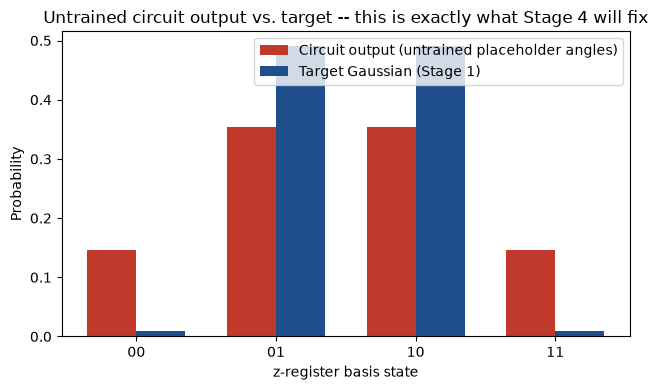

Untrained circuit output : [0.146 0.354 0.354 0.146]
Target Gaussian          : [0.009 0.491 0.491 0.009]

(As expected, these don't match yet -- closing this gap is exactly Stage 4's job.)


In [8]:
# ---- Marginal z-register distribution vs. the Stage 1 target Gaussian (untrained, for now) ----
def marginal_z_distribution(probs_dict, n_z_qubits):
    """Sums out the asset qubit to get P(z-register = b) for each b."""
    marg = np.zeros(2 ** n_z_qubits)
    for bitstring, p in probs_dict.items():
        z_bits = bitstring[1:]              # drop the leftmost (asset) character
        b = int(z_bits, 2)
        marg[b] += p
    return marg

marg_2q = marginal_z_distribution(probs_2q, n_z_qubits=2)

# Stage 1's target Gaussian histogram for the 2-qubit register (recomputed here for comparison)
z_grid_2q = discretize_z(2)
raw = np.exp(-(z_grid_2q ** 2) / 2)
target_2q = raw / raw.sum()

import matplotlib.pyplot as plt
labels = [format(b, '02b') for b in range(4)]
x = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - width/2, marg_2q, width, label='Circuit output (untrained placeholder angles)', color='#c0392b')
ax.bar(x + width/2, target_2q, width, label='Target Gaussian (Stage 1)', color='#1f4e8c')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel('z-register basis state'); ax.set_ylabel('Probability')
ax.set_title('Untrained circuit output vs. target -- this is exactly what Stage 4 will fix')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/stage03_untrained_vs_target_preview.png', dpi=150)
plt.show()

print("Untrained circuit output :", np.round(marg_2q, 4))
print("Target Gaussian          :", np.round(target_2q, 4))
print("\n(As expected, these don't match yet -- closing this gap is exactly Stage 4's job.)")


### 5.6 Saving the circuit definitions for Stage 4


In [9]:
import pickle

circuit_bundle = {
    "2_qubit": {"n_z_qubits": 2, "alpha_tilde": alpha_tilde_2q, "beta_tilde": beta_tilde_2q},
    "3_qubit": {"n_z_qubits": 3, "alpha_tilde": alpha_tilde_3q, "beta_tilde": beta_tilde_3q},
}

with open("results/circuit_design_params.json", "w") as f:
    json.dump(circuit_bundle, f, indent=2)

print("Saved -> results/circuit_design_params.json")
print(json.dumps(circuit_bundle, indent=2))
print("""
Note: we save the (alpha_tilde, beta_tilde, n_z_qubits) parameters rather than the
QuantumCircuit object itself -- Stage 4 rebuilds the circuit fresh from
build_gci_circuit(), which keeps every stage independently runnable and avoids
pickling Qiskit objects across notebook/version boundaries.
""")


Saved -> results/circuit_design_params.json
{
  "2_qubit": {
    "n_z_qubits": 2,
    "alpha_tilde": -0.12097876692308995,
    "beta_tilde": 0.7055160871779098
  },
  "3_qubit": {
    "n_z_qubits": 3,
    "alpha_tilde": -0.05184804296703855,
    "beta_tilde": 0.7055160871779098
  }
}

Note: we save the (alpha_tilde, beta_tilde, n_z_qubits) parameters rather than the
QuantumCircuit object itself -- Stage 4 rebuilds the circuit fresh from
build_gci_circuit(), which keeps every stage independently runnable and avoids
pickling Qiskit objects across notebook/version boundaries.



## 6. What This Stage Produces

1. **`build_gci_circuit()`** — a reusable function that assembles the full GCI circuit (z-register ansatz + asset encoder) for any register size.
2. **Two concrete circuits** — a 3-total-qubit version (2-qubit z-register, matching the base paper's Fig. 1 exactly) and a 4-total-qubit version (3-qubit z-register, the extension).
3. **Circuit diagrams, depth, and gate counts** for both — the pre-transpilation baseline that Stage 5 will be measured against.
4. **A verified agreement** between the real Qiskit circuit and Stage 02's hand-written NumPy proof, basis state by basis state.
5. **A visual confirmation of *why* Stage 4 is necessary** — the untrained circuit's z-register output does not yet resemble the target Gaussian.


## 7. What's Next

**Stage 4 — Classical Training (`04_classical_training.ipynb`):** takes the parameterized circuits built here and finds the z-register rotation angles $\theta_0, \dots, \theta_{n-1}$ that make the circuit's output actually match the target Gaussian histogram from `01_classical_gci_model.ipynb`. Concretely, it will:

- Evaluate `qc_2q` / `qc_3q` (via `Statevector` or `AerSimulator`) at the current $\boldsymbol\theta$,
- Compute the MSE loss against the Stage 1 target,
- Compute gradients via the parameter-shift rule (Stage 00, §3.2), applied to *this exact circuit*,
- Update $\boldsymbol\theta$ with Adam (Stage 00, §3.3),
- Repeat until the bar chart in §5.5 shows the two distributions overlapping.

---
*Next: → `04_classical_training.ipynb`*
